In [ ]:
# ============================================================================
# NOTEBOOK 03 — LSTM PARA PREDICCIÓN DE DEMANDA A 48 HORAS
# ============================================================================
# Arquitectura:
#   - Entrada: ventana de 168 horas (7 días) con demanda + features calendario
#   - Salida:  48 horas siguientes de demanda
#   - Modelo:  LSTM(128) → Dropout → LSTM(64) → Dropout → Dense(48)
#
# Comparativa contra baseline naive: MAPE 5.11% (a superar)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Verificación GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 2024
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch: 2.12.0+cu132
Device:  cuda
GPU:     NVIDIA GeForce GTX 1660
Memoria: 6.4 GB


In [ ]:
df = pd.read_csv('../data/demanda_clean.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

fecha_fin_train = pd.Timestamp('2025-07-01')
fecha_fin_val = pd.Timestamp('2026-01-01')

df_train = df[df['timestamp'] < fecha_fin_train].copy()
df_val = df[(df['timestamp'] >= fecha_fin_train) & (df['timestamp'] < fecha_fin_val)].copy()
df_test = df[df['timestamp'] >= fecha_fin_val].copy()

print(f"Train:      {len(df_train):,} horas")
print(f"Validación: {len(df_val):,} horas")
print(f"Test:       {len(df_test):,} horas")

Train:      21,889 horas
Validación: 4,416 horas
Test:       2,878 horas


In [ ]:
# Variable objetivo: demanda_mw
# Features de entrada: demanda_mw + 10 features de calendario
FEATURES = [
    'demanda_mw',
    'hora_sin', 'hora_cos',
    'dia_sin', 'dia_cos',
    'mes_sin', 'mes_cos',
    'es_finde', 'es_festivo',
]
TARGET = 'demanda_mw'

# Normalizamos con el train
scaler = StandardScaler()
scaler.fit(df_train[FEATURES].values)

X_train_scaled = scaler.transform(df_train[FEATURES].values)
X_val_scaled = scaler.transform(df_val[FEATURES].values)
X_test_scaled = scaler.transform(df_test[FEATURES].values)


target_scaler = StandardScaler()
target_scaler.fit(df_train[[TARGET]].values)

y_train_scaled = target_scaler.transform(df_train[[TARGET]].values).flatten()
y_val_scaled = target_scaler.transform(df_val[[TARGET]].values).flatten()
y_test_scaled = target_scaler.transform(df_test[[TARGET]].values).flatten()

print(f"X_train shape: {X_train_scaled.shape}")
print(f"Features:      {len(FEATURES)}")
print(f"Media train:   {df_train[TARGET].mean():.1f} MW")
print(f"Std train:     {df_train[TARGET].std():.1f} MW")

X_train shape: (21889, 9)
Features:      9
Media train:   26646.4 MW
Std train:     4210.7 MW


In [ ]:
INPUT_LEN = 168    # 7 días de historial
OUTPUT_LEN = 48    # predecir 48 horas siguientes

class VentanaDataset(Dataset):
    """
    Cada muestra:
      - X: matriz (168 × n_features) con demanda + features de calendario
      - y: vector (48,) con la demanda real de las 48h siguientes
    """
    def __init__(self, X_features, y_target, input_len=168, output_len=48):
        self.X = X_features
        self.y = y_target
        self.input_len = input_len
        self.output_len = output_len
        # Total de ventanas que podemos generar
        self.n_samples = len(X_features) - input_len - output_len + 1
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        x_window = self.X[idx : idx + self.input_len]
        y_window = self.y[idx + self.input_len : idx + self.input_len + self.output_len]
        return (
            torch.tensor(x_window, dtype=torch.float32),
            torch.tensor(y_window, dtype=torch.float32),
        )

train_ds = VentanaDataset(X_train_scaled, y_train_scaled, INPUT_LEN, OUTPUT_LEN)
val_ds = VentanaDataset(X_val_scaled, y_val_scaled, INPUT_LEN, OUTPUT_LEN)
test_ds = VentanaDataset(X_test_scaled, y_test_scaled, INPUT_LEN, OUTPUT_LEN)

print(f"Ventanas train: {len(train_ds):,}")
print(f"Ventanas val:   {len(val_ds):,}")
print(f"Ventanas test:  {len(test_ds):,}")

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

x_sample, y_sample = next(iter(train_loader))
print(f"\nForma batch X: {x_sample.shape}  (batch × time × features)")
print(f"Forma batch y: {y_sample.shape}  (batch × horizonte)")

Ventanas train: 21,674
Ventanas val:   4,201
Ventanas test:  2,663

Forma batch X: torch.Size([64, 168, 9])  (batch × time × features)
Forma batch y: torch.Size([64, 48])  (batch × horizonte)


In [ ]:
class LSTMDemanda(nn.Module):
    """
    LSTM encoder + Dense decoder para predicción multistep.
    Arquitectura:
      LSTM(128, return_sequences=True) → Dropout(0.3)
      LSTM(64)                          → Dropout(0.3)
      Dense(48)                          → salida lineal
    """
    def __init__(self, n_features, output_len=48,
                 lstm1_units=128, lstm2_units=64, dropout=0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(
            input_size=n_features,
            hidden_size=lstm1_units,
            num_layers=1,
            batch_first=True,
        )
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(
            input_size=lstm1_units,
            hidden_size=lstm2_units,
            num_layers=1,
            batch_first=True,
        )
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm2_units, output_len)
    
    def forward(self, x):
        # x: (batch, 168, n_features)
        out, _ = self.lstm1(x)       # (batch, 168, 128)
        out = self.dropout1(out)
        out, (h, c) = self.lstm2(out) # (batch, 168, 64)
        out = self.dropout2(out)
        out = out[:, -1, :]           # (batch, 64)
        out = self.fc(out)            # (batch, 48)
        return out

modelo = LSTMDemanda(n_features=len(FEATURES), output_len=OUTPUT_LEN).to(device)
print(modelo)

n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {n_params:,}")

LSTMDemanda(
  (lstm1): LSTM(9, 128, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=48, bias=True)
)

Parámetros entrenables: 123,952


In [ ]:
N_EPOCHS = 50
LR = 1e-3
PATIENCE = 8   # early stopping

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)


historial = {'train_loss': [], 'val_loss': []}
mejor_val_loss = float('inf')
mejor_epoch = 0
contador_paciencia = 0
mejor_modelo_state = None

print(f"Optimizer:     Adam, lr={LR}")
print(f"Loss:          MSE")
print(f"Epochs máx:    {N_EPOCHS}")
print(f"Early stop:    patience={PATIENCE}")
print(f"Scheduler:     ReduceLROnPlateau(factor=0.5, patience=3)")

Optimizer:     Adam, lr=0.001
Loss:          MSE
Epochs máx:    50
Early stop:    patience=8
Scheduler:     ReduceLROnPlateau(factor=0.5, patience=3)


In [41]:
import time

print("="*60)
print("INICIANDO ENTRENAMIENTO LSTM")
print("="*60)
start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    # --- TRAIN ---
    modelo.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = modelo(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        # Gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())
    
    # --- VALIDATION ---
    modelo.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = modelo(X_batch)
            loss = criterion(y_pred, y_batch)
            val_losses.append(loss.item())
    
    train_loss_avg = np.mean(train_losses)
    val_loss_avg = np.mean(val_losses)
    historial['train_loss'].append(train_loss_avg)
    historial['val_loss'].append(val_loss_avg)
    
    scheduler.step(val_loss_avg)
    
    # Early stopping
    if val_loss_avg < mejor_val_loss:
        mejor_val_loss = val_loss_avg
        mejor_epoch = epoch
        contador_paciencia = 0
        # Guardar estado del mejor modelo
        mejor_modelo_state = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}
    else:
        contador_paciencia += 1
    
    print(f"Epoch {epoch:>2}/{N_EPOCHS}  "
          f"train_loss={train_loss_avg:.5f}  "
          f"val_loss={val_loss_avg:.5f}  "
          f"lr={optimizer.param_groups[0]['lr']:.1e}  "
          f"{'← mejor' if contador_paciencia == 0 else ''}")
    
    if contador_paciencia >= PATIENCE:
        print(f"\nEarly stopping en epoch {epoch} (sin mejora en {PATIENCE} epochs)")
        break

elapsed = time.time() - start
print(f"\n{'='*60}")
print(f"Tiempo total: {elapsed:.1f}s  ({elapsed/60:.1f} min)")
print(f"Mejor epoch:  {mejor_epoch}  (val_loss={mejor_val_loss:.5f})")
print(f"{'='*60}")

# Cargar el mejor modelo
modelo.load_state_dict(mejor_modelo_state)
modelo = modelo.to(device)
print("✓ Modelo restaurado a su mejor estado")

INICIANDO ENTRENAMIENTO LSTM
Epoch  1/50  train_loss=0.29306  val_loss=0.13735  lr=1.0e-03  ← mejor
Epoch  2/50  train_loss=0.14367  val_loss=0.12216  lr=1.0e-03  ← mejor
Epoch  3/50  train_loss=0.13041  val_loss=0.11346  lr=1.0e-03  ← mejor
Epoch  4/50  train_loss=0.12523  val_loss=0.10467  lr=1.0e-03  ← mejor
Epoch  5/50  train_loss=0.12047  val_loss=0.10625  lr=1.0e-03  
Epoch  6/50  train_loss=0.11654  val_loss=0.10169  lr=1.0e-03  ← mejor
Epoch  7/50  train_loss=0.11344  val_loss=0.10935  lr=1.0e-03  
Epoch  8/50  train_loss=0.11001  val_loss=0.10583  lr=1.0e-03  
Epoch  9/50  train_loss=0.10703  val_loss=0.11024  lr=1.0e-03  
Epoch 10/50  train_loss=0.10388  val_loss=0.10585  lr=5.0e-04  
Epoch 11/50  train_loss=0.09768  val_loss=0.09950  lr=5.0e-04  ← mejor
Epoch 12/50  train_loss=0.09501  val_loss=0.10929  lr=5.0e-04  
Epoch 13/50  train_loss=0.09308  val_loss=0.09972  lr=5.0e-04  
Epoch 14/50  train_loss=0.09205  val_loss=0.10156  lr=5.0e-04  
Epoch 15/50  train_loss=0.09005  

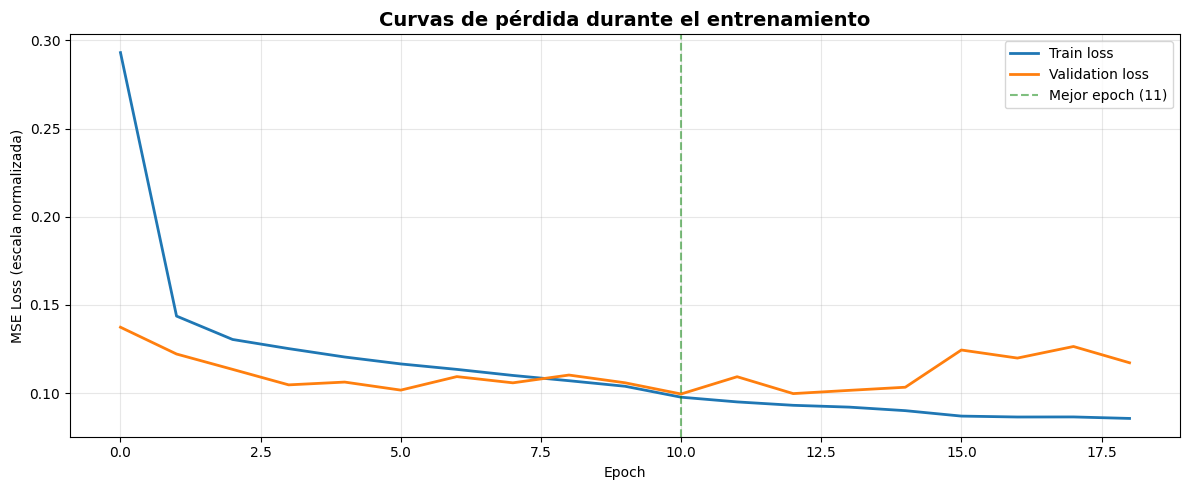

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(historial['train_loss'], label='Train loss', linewidth=2)
ax.plot(historial['val_loss'], label='Validation loss', linewidth=2)
ax.axvline(mejor_epoch - 1, color='green', linestyle='--', alpha=0.5, label=f'Mejor epoch ({mejor_epoch})')
ax.set_title('Curvas de pérdida durante el entrenamiento', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (escala normalizada)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/curvas_loss.png', bbox_inches='tight')
plt.show()

In [43]:
modelo.eval()
predicciones = []
reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = modelo(X_batch).cpu().numpy()
        predicciones.append(y_pred)
        reales.append(y_batch.numpy())

predicciones = np.vstack(predicciones)  # (n_ventanas, 48)
reales = np.vstack(reales)              # (n_ventanas, 48)
print(f"Forma predicciones: {predicciones.shape}")
print(f"Forma reales:       {reales.shape}")

# Desnormalizar
predicciones_mw = target_scaler.inverse_transform(predicciones)
reales_mw = target_scaler.inverse_transform(reales)

# Métricas globales (todas las predicciones de 48h aplanadas)
y_true_flat = reales_mw.flatten()
y_pred_flat = predicciones_mw.flatten()

mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mape = np.mean(np.abs((y_true_flat - y_pred_flat) / y_true_flat)) * 100

print("\n" + "="*50)
print("MÉTRICAS LSTM EN TEST")
print("="*50)
print(f"MAE:  {mae:>9.2f} MW")
print(f"RMSE: {rmse:>9.2f} MW")
print(f"MAPE: {mape:>9.2f} %")
print("="*50)

# Comparativa con baseline naive
print("\nCOMPARATIVA vs BASELINE NAIVE:")
print(f"  MAPE Naive:  5.11%")
print(f"  MAPE LSTM:   {mape:.2f}%")
mejora = (5.11 - mape) / 5.11 * 100
print(f"  Mejora:      {mejora:+.1f}%")

Forma predicciones: (2663, 48)
Forma reales:       (2663, 48)

MÉTRICAS LSTM EN TEST
MAE:     922.13 MW
RMSE:   1213.76 MW
MAPE:      3.34 %

COMPARATIVA vs BASELINE NAIVE:
  MAPE Naive:  5.11%
  MAPE LSTM:   3.34%
  Mejora:      +34.7%


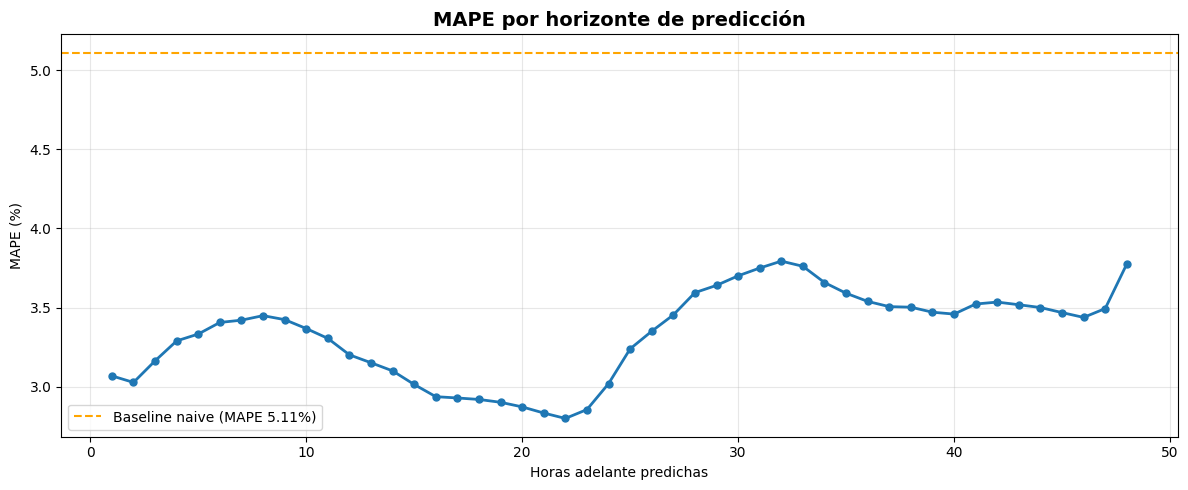

MAPE en h+1:   3.07%
MAPE en h+24:  3.02%
MAPE en h+48:  3.78%


In [44]:
# Calculamos MAPE para cada una de las 48 horas predichas
mape_por_hora = []
for h in range(OUTPUT_LEN):
    y_t = reales_mw[:, h]
    y_p = predicciones_mw[:, h]
    mape_h = np.mean(np.abs((y_t - y_p) / y_t)) * 100
    mape_por_hora.append(mape_h)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, OUTPUT_LEN+1), mape_por_hora, marker='o', linewidth=2, markersize=5)
ax.axhline(5.11, color='orange', linestyle='--', label=f'Baseline naive (MAPE 5.11%)')
ax.set_title('MAPE por horizonte de predicción', fontsize=14, fontweight='bold')
ax.set_xlabel('Horas adelante predichas')
ax.set_ylabel('MAPE (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/mape_por_horizonte.png', bbox_inches='tight')
plt.show()

print(f"MAPE en h+1:   {mape_por_hora[0]:.2f}%")
print(f"MAPE en h+24:  {mape_por_hora[23]:.2f}%")
print(f"MAPE en h+48:  {mape_por_hora[47]:.2f}%")

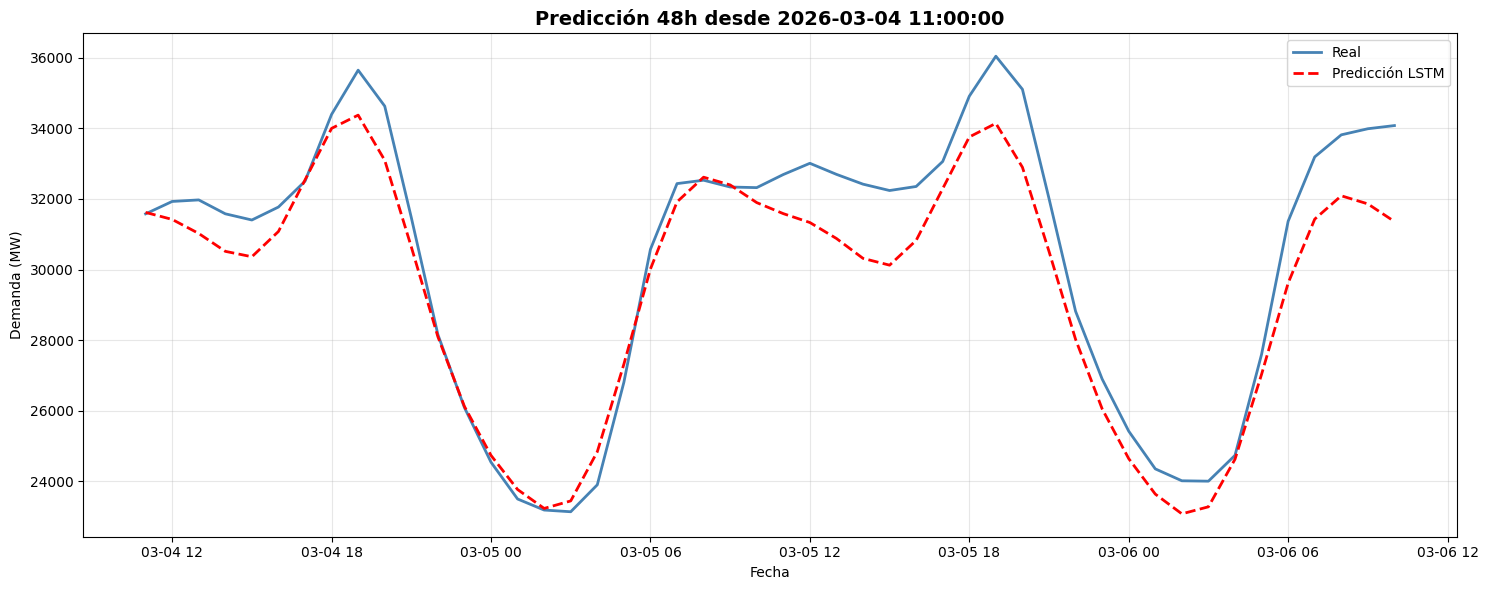

In [ ]:
# Cogemos una ventana aleatoria del test para visualizar
idx_ejemplo = len(test_ds) // 2  

x_window, y_real = test_ds[idx_ejemplo]
x_window_dev = x_window.unsqueeze(0).to(device)

with torch.no_grad():
    y_pred = modelo(x_window_dev).cpu().numpy().flatten()

# Desnormalizar
y_pred_mw = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_real_mw = target_scaler.inverse_transform(y_real.numpy().reshape(-1, 1)).flatten()

# Timestamp inicial de la ventana de predicción
n_test_inicio = len(df) - len(df_test)
ts_inicio_pred = df_test.iloc[INPUT_LEN + idx_ejemplo]['timestamp']

fig, ax = plt.subplots(figsize=(15, 6))
horas = pd.date_range(start=ts_inicio_pred, periods=OUTPUT_LEN, freq='1h')
ax.plot(horas, y_real_mw, label='Real', color='steelblue', linewidth=2)
ax.plot(horas, y_pred_mw, label='Predicción LSTM', color='red', linewidth=2, linestyle='--')
ax.set_title(f'Predicción 48h desde {ts_inicio_pred}', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../docs/capturas/prediccion_ejemplo.png', bbox_inches='tight')

In [46]:
import os
os.makedirs('../model', exist_ok=True)

# Guardar el modelo entrenado
torch.save({
    'modelo_state_dict': modelo.state_dict(),
    'input_features': FEATURES,
    'input_len': INPUT_LEN,
    'output_len': OUTPUT_LEN,
    'mejor_epoch': mejor_epoch,
    'mejor_val_loss': float(mejor_val_loss),
}, '../model/lstm_demanda.pt')

# Guardar scalers (para la inferencia futura)
import pickle
with open('../model/scalers.pkl', 'wb') as f:
    pickle.dump({'feature_scaler': scaler, 'target_scaler': target_scaler}, f)

# Guardar métricas y comparativa
resultados = {
    'modelo': 'LSTM PyTorch',
    'arquitectura': 'LSTM(128) → Dropout → LSTM(64) → Dropout → Dense(48)',
    'parametros': int(n_params),
    'entrenamiento': {
        'epochs_totales': len(historial['train_loss']),
        'mejor_epoch': int(mejor_epoch),
        'mejor_val_loss': float(mejor_val_loss),
    },
    'metricas_test': {
        'MAE_MW': round(float(mae), 2),
        'RMSE_MW': round(float(rmse), 2),
        'MAPE_pct': round(float(mape), 2),
    },
    'comparativa_baseline': {
        'MAPE_naive_pct': 5.11,
        'MAPE_lstm_pct': round(float(mape), 2),
        'mejora_pct': round(float((5.11 - mape) / 5.11 * 100), 2),
    }
}

with open('../resultados_lstm.json', 'w') as f:
    json.dump(resultados, f, indent=2)

print("✓ Modelo guardado en: lstm-local/model/lstm_demanda.pt")
print("✓ Scalers guardados en: lstm-local/model/scalers.pkl")
print("✓ Métricas guardadas en: lstm-local/resultados_lstm.json")
print("\n" + json.dumps(resultados, indent=2))

✓ Modelo guardado en: lstm-local/model/lstm_demanda.pt
✓ Scalers guardados en: lstm-local/model/scalers.pkl
✓ Métricas guardadas en: lstm-local/resultados_lstm.json

{
  "modelo": "LSTM PyTorch",
  "arquitectura": "LSTM(128) \u2192 Dropout \u2192 LSTM(64) \u2192 Dropout \u2192 Dense(48)",
  "parametros": 123952,
  "entrenamiento": {
    "epochs_totales": 19,
    "mejor_epoch": 11,
    "mejor_val_loss": 0.0994953823304086
  },
  "metricas_test": {
    "MAE_MW": 922.13,
    "RMSE_MW": 1213.76,
    "MAPE_pct": 3.34
  },
  "comparativa_baseline": {
    "MAPE_naive_pct": 5.11,
    "MAPE_lstm_pct": 3.34,
    "mejora_pct": 34.73
  }
}


In [ ]:
# ============================================================================
# EXPORTAR PREDICCIONES DEL LSTM PARA MONGODB (versión compacta)
# ============================================================================
# Por cada timestamp del test guardamos UNA predicción: la que hace la ventana
# más reciente que apunta a ese timestamp como su horizonte h+1.
# Resultado: 2.663 registros, uno por hora del test.
# ============================================================================

import pandas as pd

n_ventanas = predicciones_mw.shape[0]
print(f"Ventanas totales: {n_ventanas:,}")

# Cada ventana idx_ventana predice 48 horas a partir de df_test.iloc[INPUT_LEN + idx_ventana]
# La predicción "h+1" de cada ventana es la primera columna [:, 0] de predicciones_mw

registros = []
for idx_ventana in range(n_ventanas):
    # Timestamp al que apunta la primera hora predicha de esta ventana
    ts_prediccion = df_test.iloc[INPUT_LEN + idx_ventana]['timestamp']
    
    real = float(reales_mw[idx_ventana, 0])      # demanda real h+1
    pred = float(predicciones_mw[idx_ventana, 0]) # predicción h+1
    
    registros.append({
        'timestamp': pd.Timestamp(ts_prediccion).isoformat(),
        'demanda_real_mw':     round(real, 2),
        'demanda_predicha_mw': round(pred, 2),
        'error_abs_mw':        round(abs(real - pred), 2),
        'error_pct':           round(abs(real - pred) / real * 100, 3),
    })

df_pred = pd.DataFrame(registros)
print(f"Total registros: {len(df_pred):,}")
print(df_pred.head())

# Exportar
df_pred.to_csv('../data/predicciones_lstm.csv', index=False)
print(f"\n✓ Guardado: lstm/predicciones_lstm.csv")
print(f"  Tamaño: {df_pred.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"  Cobertura: {df_pred['timestamp'].min()}  →  {df_pred['timestamp'].max()}")

Ventanas totales: 2,663
Total registros: 2,663
             timestamp  demanda_real_mw  demanda_predicha_mw  error_abs_mw  \
0  2026-01-08T00:00:00         26908.09             26399.57        508.52   
1  2026-01-08T01:00:00         25564.19             25328.06        236.13   
2  2026-01-08T02:00:00         25070.34             24610.15        460.19   
3  2026-01-08T03:00:00         24999.14             24896.43        102.72   
4  2026-01-08T04:00:00         25693.91             26595.40        901.48   

   error_pct  
0      1.890  
1      0.924  
2      1.836  
3      0.411  
4      3.509  

✓ Guardado: lstm/predicciones_lstm.csv
  Tamaño: 281.0 KB
  Cobertura: 2026-01-08T00:00:00  →  2026-04-28T22:00:00


In [48]:
print("="*60)
print("RESUMEN ENTRENAMIENTO LSTM")
print("="*60)
print(f"Arquitectura:    LSTM(128) → Dropout(0.3) → LSTM(64) → Dropout(0.3) → Dense(48)")
print(f"Parámetros:      {n_params:,}")
print(f"Ventana entrada: {INPUT_LEN}h (7 días)")
print(f"Horizonte:       {OUTPUT_LEN}h (48 horas)")
print(f"Features:        {len(FEATURES)} (demanda + 8 calendario)")
print()
print(f"Entrenamiento:   {len(historial['train_loss'])} epochs (early stop en {mejor_epoch})")
print(f"Tiempo total:    {elapsed:.0f}s")
print(f"Dispositivo:     {device}")
print()
print(f"MÉTRICAS TEST:")
print(f"  MAE:  {mae:>8.2f} MW")
print(f"  RMSE: {rmse:>8.2f} MW")
print(f"  MAPE: {mape:>8.2f}%")
print()
print(f"VS BASELINE NAIVE:")
print(f"  Naive: 5.11%   LSTM: {mape:.2f}%   Mejora: {(5.11-mape)/5.11*100:+.1f}%")
print("="*60)

RESUMEN ENTRENAMIENTO LSTM
Arquitectura:    LSTM(128) → Dropout(0.3) → LSTM(64) → Dropout(0.3) → Dense(48)
Parámetros:      123,952
Ventana entrada: 168h (7 días)
Horizonte:       48h (48 horas)
Features:        9 (demanda + 8 calendario)

Entrenamiento:   19 epochs (early stop en 11)
Tiempo total:    75s
Dispositivo:     cuda

MÉTRICAS TEST:
  MAE:    922.13 MW
  RMSE:  1213.76 MW
  MAPE:     3.34%

VS BASELINE NAIVE:
  Naive: 5.11%   LSTM: 3.34%   Mejora: +34.7%
